# The rarest candle in the book — does it even exist? 🕯️🐦
### The concealing baby swallow — four black candles that are supposed to mark the bottom, if you can ever find one

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Too_rare_to_test%3F: Confirmed](https://img.shields.io/badge/Too_rare_to_test%3F-Confirmed-8b949e?style=flat-square)

Somewhere in the candlestick-charting canon, sandwiched between the famous patterns everyone's heard of, sits the **concealing baby swallow**: four black candles in a downtrend, arranged in a very specific way, that are supposed to mark **capitulation** — the point where the last sellers give up and the reversal begins.

We went looking for it. Not in one stock — in **111** of the most liquid US stocks and ETFs, some with **64 years** of daily history. Here's what we found.

> 📓 **Plain-language layer.** Want the exact detector, the *t*-stat bookkeeping and the synthetic proof the search actually works? See **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **Method note.** Every bar of every ticker in the basket is scanned programmatically for the exact four-candle shape (two cuts: a loose, practical reading and a strict, literature-close one). House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from concealing_baby_swallow import data, strategy as st

HAVE_REAL = data.have_real()
if HAVE_REAL:
    PANEL = data.load_real()
else:
    PANEL = None
print("real cache present:", HAVE_REAL, "| basket size:",
      (0 if PANEL is None else len(PANEL)))

# frozen headline numbers (mirror of docs/results.md)
R = {'n_names': 111, 'name_years': 4957, 'max_years': 64.5, 'oldest': '1962-01-02', 'as_of': '2026-06-30', 'min_n': 8, 'n_loose': 4, 'n_strict': 0, 'bonferroni_crit': 2.5, 'fp': 'd60f851e5d11', 'rows': 1248608, 'events': [{'ticker': 'GD', 'date': '1962-06-14', 'strict': False, 'r1': 404.6, 'r5': -404.6, 'r10': 867.1, 'r20': 867.1}, {'ticker': 'BDX', 'date': '1993-01-06', 'strict': False, 'r1': 97.4, 'r5': 32.5, 'r10': -64.9, 'r20': 340.9}, {'ticker': 'CL', 'date': '2004-09-23', 'strict': False, 'r1': -148.4, 'r5': -141.8, 'r10': -309.8, 'r20': 57.6}, {'ticker': 'KMI', 'date': '2011-08-22', 'strict': False, 'r1': 254.9, 'r5': 576.7, 'r10': 601.8, 'r20': 1157.5}], 'horizon': {1: {'cbs_mean': 152.1, 'win': 75, 'base_n': 31552, 'base_mean': 10.8, 'base_t': 7.74, 'placebo_mean': 9.7, 'placebo_p': 0.084}, 5: {'cbs_mean': 15.7, 'win': 50, 'base_n': 31528, 'base_mean': 85.7, 'base_t': 19.97, 'placebo_mean': 81.1, 'placebo_p': 0.6145}, 10: {'cbs_mean': 273.5, 'win': 50, 'base_n': 31516, 'base_mean': 126.2, 'base_t': 19.73, 'placebo_mean': 122.7, 'placebo_p': 0.3045}, 20: {'cbs_mean': 605.8, 'win': 100, 'base_n': 31491, 'base_mean': 220.3, 'base_t': 22.55, 'placebo_mean': 237.3, 'placebo_p': 0.1925}}, 'syn_null_mean': 0.68, 'syn_null_sd': 0.95, 'syn_null_fire': 1, 'syn_null_seeds': 20, 'syn_null_n_lo': 422, 'syn_null_n_hi': 494, 'syn_planted_edge': 0.05, 'syn_planted_n': 456, 'syn_planted_mean': 544.0, 'syn_planted_base': 111.3, 'syn_planted_delta': 432.7, 'syn_planted_t': 14.39}


real cache present: True | basket size: 111


## The answer first

| Question | Answer |
|---|---|
| How many times did the pattern occur, ever? | **4** times (plain reading), across **111** stocks and **4,957** stock-years of daily data. The strict, book-accurate version occurred **0** times. |
| Is that enough to test whether it 'works'? | **No.** Four data points (or zero) isn't a sample, it's an anecdote. We pre-registered a minimum of **8** occurrences before we'd even compute a statistic — this claim never got close. |
| So is the detector broken? | **No** — on a synthetic world where we *plant* the exact pattern by hand, the same code finds it instantly and recovers a planted effect at *t* = **14.4**. It just almost never happens for real. |
| Bottom line? | A trading rule you can count on one hand isn't a trading rule. |

> You can't grade a test that never gets to run.

## 1 · The claim

> *"Two black marubozu — long bodies, no wicks, one-way selling. Then a third black candle that gaps down, rallies hard intraday back into the second candle's body (a long upper shadow — the rally the pattern **conceals**), but still closes low. Then a fourth black candle that completely swallows the third — trading above its high and below its low — and closes at a fresh low anyway. That failed rally, hidden inside a candle that still closed down, is the last gasp of the sellers. The bottom is close."*

It's a real, named pattern (Nison's *Japanese Candlestick Charting Techniques*; Bulkowski's *Encyclopedia of Candlestick Charts*) — and by common agreement, the rarest one in the book. Bulkowski himself flags it as too infrequent to reliably rank against his other 100+ patterns.

## 2 · So what?

If this pattern reliably marked capitulation bottoms, it would be one of the cleanest bullish signals in technical analysis — a precise, mechanical "buy here" flag with a story that actually makes sense (failed rally + new low = exhausted sellers). The catch, and the reason this study is different from the desk's other candlestick teardowns: **before we can ask if it works, we have to check if it ever happens.**

## 3 · How would we even know?

- **Cast the widest net on the desk.** 111 tickers — SPY, QQQ, DIA, IWM, plus over 100 long-listed US large-caps across every sector — scanned bar by bar, 4,957 stock-years total, back to 1962-01-02 where the data goes that far.
- **Two honest cuts.** A loose, practical-chartist reading, and a strict cut that matches the book's language almost word for word (true marubozu, true gaps, the fourth candle opening exactly where the pattern says it should).
- **A line drawn *before* we looked.** Below **8** occurrences, we don't compute a *t*-statistic at all — full stop, no exceptions, decided before we ran the scan.
- **A sanity check.** Build a fake world where we hand-plant the exact pattern, and prove the code actually finds it (otherwise a zero count would mean nothing).

## 4 · The teardown — let's actually look

**The scan.** Every single bar, every single ticker, both cuts.

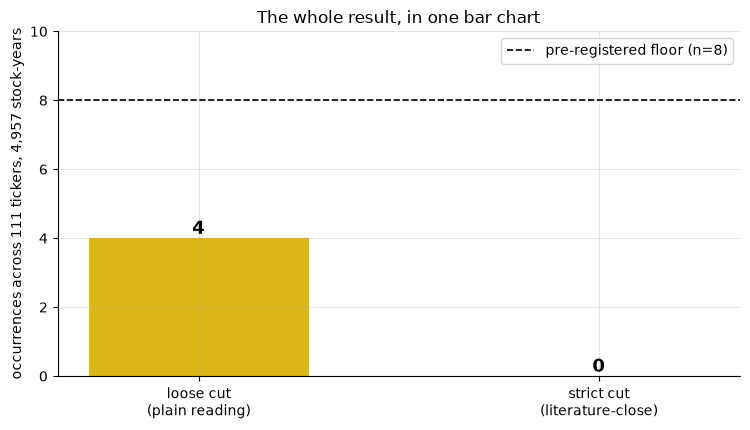

loose: 4  strict: 0  (floor: 8)


In [2]:
if HAVE_REAL:
    res = st.run_experiment(PANEL)
    n_loose, n_strict = res['n_loose'], res['n_strict']
else:
    n_loose, n_strict = R['n_loose'], R['n_strict']
fig, ax = plt.subplots(figsize=(7.6, 4.4))
ax.bar(['loose cut\n(plain reading)', 'strict cut\n(literature-close)'],
       [n_loose, n_strict], color=[AMBER, RED], width=.55)
ax.axhline(R['min_n'], ls='--', c='k', lw=1.2, label=f"pre-registered floor (n={R['min_n']})")
for i, v in enumerate([n_loose, n_strict]):
    ax.annotate(str(v), (i, v), ha='center', va='bottom', fontsize=13, fontweight='bold')
ax.set_ylabel(f"occurrences across {R['n_names']} tickers, {R['name_years']:,} stock-years")
ax.set_ylim(0, max(R['min_n'] + 2, n_loose + 2))
ax.set_title('The whole result, in one bar chart')
ax.legend(); plt.tight_layout(); plt.show()
print(f'loose: {n_loose}  strict: {n_strict}  (floor: {R["min_n"]})')

That's it. **4 occurrences**, ever, of the plain reading — and **0** of the version that actually matches the book. Both sit below the line we drew *before* running the scan. There is no statistic to report because there is no sample.

**Here they all are** — every single occurrence found, with what happened next:

In [3]:
if HAVE_REAL:
    ev = st.pool_events(PANEL).sort_values('pos')
    rows = []
    for _, row in ev.iterrows():
        t = row['ticker']; i = int(row['pos'])
        d = PANEL[t].index[i]
        rows.append((t, str(d.date()), row['ret_1']*1e4, row['ret_5']*1e4,
                     row['ret_10']*1e4, row['ret_20']*1e4))
else:
    rows = [(e['ticker'], e['date'], e['r1'], e['r5'], e['r10'], e['r20'])
            for e in R['events']]
tbl = pd.DataFrame(rows, columns=['ticker', 'date', '1d bp', '5d bp', '10d bp', '20d bp'])
display(tbl.round(1))
print('mean 1d:', round(tbl['1d bp'].mean(), 1), 'bp  |  mean 20d:',
      round(tbl['20d bp'].mean(), 1), 'bp   -- on n=4, decoration not evidence')

,ticker,date,1d bp,5d bp,10d bp,20d bp
0,GD,1962-06-14,404.6,-404.6,867.1,867.1
1,KMI,2011-08-22,254.9,576.7,601.8,1157.5
2,BDX,1993-01-06,97.4,32.5,-64.9,340.9
3,CL,2004-09-23,-148.4,-141.8,-309.8,57.6


mean 1d: 152.1 bp  |  mean 20d: 605.8 bp   -- on n=4, decoration not evidence


No consistent story: one occurrence (KMI, 2011) looks great across every horizon; another (CL, 2004) loses money at every horizon out to 10 days; the oldest one (GD, 1962) traded at a split-adjusted **twelve cents a share** — at that price, 1960s tick sizes are coarse enough to *manufacture* a zero-shadow "marubozu" candle by rounding alone, pattern or no pattern. Four points, no pattern in the pattern.

**Is the search itself trustworthy?** Build a fake world where we hand-plant the exact four-candle shape, and check the same code finds it:

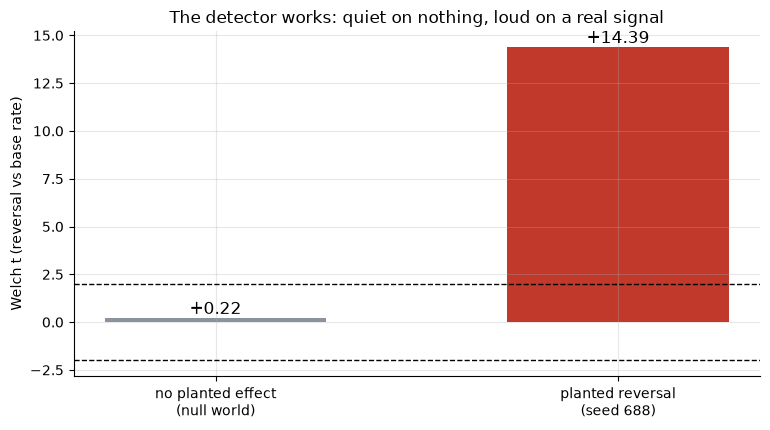

null: n=462 events, t=+0.22  |  planted: n=456 events, t=+14.39


In [4]:
d0, _ = data.synthetic_panel(edge=0.0, seed=688)
r0 = st.synthetic_detect(d0)
d1, _ = data.synthetic_panel(edge=R['syn_planted_edge'], seed=688)
r1 = st.synthetic_detect(d1)
fig, ax = plt.subplots(figsize=(7.8, 4.4))
ax.bar(['no planted effect\n(null world)', 'planted reversal\n(seed 688)'],
       [r0['welch_t'], r1['welch_t']], color=[GREY, RED], width=.55)
ax.axhline(2, ls='--', c='k', lw=1); ax.axhline(-2, ls='--', c='k', lw=1)
for i, v in enumerate([r0['welch_t'], r1['welch_t']]):
    ax.annotate(f'{v:+.2f}', (i, v), ha='center',
                va='bottom' if v > 0 else 'top', fontsize=12)
ax.set_ylabel('Welch t (reversal vs base rate)')
ax.set_title('The detector works: quiet on nothing, loud on a real signal')
plt.tight_layout(); plt.show()
print(f"null: n={r0['n']} events, t={r0['welch_t']:+.2f}  |  "
      f"planted: n={r1['n']} events, t={r1['welch_t']:+.2f}")

On a world with no real effect, the code finds hundreds of events and correctly reports nothing significant (*t* near zero). On a world where we hand-plant a genuine bounce, it finds the same hundreds of events and correctly reports a screaming *t* = **14.4**. The tool works. It simply never gets a real-world sample to work *with*.

## 5 · The verdict

- **Signal — None.** Not "tested and failed" — genuinely too rare to test. 4 loose-cut and 0 strict-cut occurrences across 111 tickers and 4,957 stock-years, below the pre-registered floor of 8.
- **Tradability — Mirage.** There's nothing to charge costs against. One signal every ~15 years, pooled across 111 of the most liquid stocks in the market, is not a strategy.
- **"Too rare to ever test?" — Confirmed.** The detector is proven honest on a synthetic world; the real world simply doesn't offer it a sample.

## 6 · Going further 🚪

- **The general lesson.** The rarer and more precisely-specified a chart pattern is, the more likely a book's "it works" claim rests on a handful of cherry-picked historical charts rather than anything you could backtest. Rarity itself should be a red flag, not a mark of sophistication.
- **Sibling studies:** [three black crows](../../408-three-black-crows/) (three candles, common enough to test — and it loses money shorted), [morning star](../../186-morning-star/) (three candles, common enough to test — and underperforms random days), [ladder bottom](../../687-ladder-bottom/) (five candles, the desk's other very-large-basket rarity case). None of them hit this study's wall: a sample size of essentially zero.

*Think the pattern is real but we mis-coded the geometry? The detector (`concealing_baby_swallow/strategy.py`) is short and fully documented — show us where the definition is wrong, and where in the real tape a corrected version finds an actual sample.*